## 🌟 **Análise Exploratória dos Dados**

🧭
Este notebook realiza a análise exploratória dos dados, que consiste no download da base de dados, filtragem e reconhecimento do formato, de modo a preparar os dados para a detecção. O objetivo é ter algumas primeiras noções acerca do dataset. Para isso, serão executados os seguintes passos:

- ✅ 1. Importação de Bibliotecas
- ✅ 2. Download dos datasets
- ✅ 3. Leitura dos datasets
- ✅ 4. Filtragem do dataset
- ✅ 5. Visualização da imagem

#### 📚 **1. Importação de bibliotecas**

🛠️
Para essa notebook, serão necessárias bibliotecas para processamento de imagens, visualização e manipulação de Sistema Operacional, a fim de permitir operações dentro do dataset, além da biblioteca que será utilizada para baixar o dataset.
🧩

In [17]:
import os # operações de arquivos e diretórios
import cv2 # processamento de imagens e visão computacional
import matplotlib.pyplot as plt # visualização de imagens e gráficos
import kagglehub # download de datasets do Kaggle
from pycocotools.coco import COCO # manipulação de datasets no formato COCO

#### ⬇️ **2. Download dos datasets**

📥
Nessa seção, utilizando a biblioteca Kagglehub, o dataset que será utilizado será baixado através do Kaggle. Foi a forma selecionada para download por possuir uma performance melhor, já que, por ser um dataset muito grande, tende a demorar mais tempo.

⚠️ **Atenção:** Ao executar a célula abaixo, o dataset será baixado no diretório da sua máquina, pesando em torno de 1.65GB. Caso não queira ocupar esse espaço de memória em seu computador, é recomendado que a célula abaixo não seja executada. 

Caso queira remover os arquivos que foram baixados no kaggle, **navegue até o diretório** mapeado na célula abaixo e **remova os arquivos**.
📦

In [18]:
# Realiza o download do dataset do Kaggle
kaggle_path = kagglehub.dataset_download("mathlouren/projeto-ia-dados")
kaggle_path

'C:\\Users\\mathl\\.cache\\kagglehub\\datasets\\mathlouren\\projeto-ia-dados\\versions\\3'

#### 📖 **3. Leitura dos Datasets**

🔎
Para leitura do dataset, será utilizada a biblioteca pycocotools, que lerá as anotações (características e classificações da imagem) do dataset a partir do caminho gerado no download. Para isso, será inicializado um objeto COCO para leitura do json com as annotations.
🧠

🗺️
**Mapeamento de caminhos**
🗂️

In [19]:
# Caminhos para os ficheiros 
ann_file = kaggle_path + '/annotations_trainval2017/annotations/instances_val2017.json'
img_dir = kaggle_path +'/val2017/val2017'

⚙️
**Inicialização do Objeto COCO**
🤖

In [20]:
# Inicializa o objeto COCO para ler as anotações
coco = COCO(ann_file)

loading annotations into memory...
Done (t=0.79s)
creating index...
index created!


#### 🧹 **4. Filtragem do Dataset**

🎯
Nessa seção, o dataset lido pelo objeto COCO será filtrado, em que sejam obtidas somente aqueles com a classe person. A filtragem é feita a partir de operações do próprio objeto COCO.
✅

👤
**Filtrar apenas a categoria person**
🔍

In [21]:
# Filtrar apenas a categoria "person" (ID 1 no COCO dataset)
catIds = coco.getCatIds(catNms=['person'])
imgIds = coco.getImgIds(catIds=catIds)

# Mostrar estatísticas dos dados filtrados
images_total = len(coco.getImgIds())
people_images = len(imgIds)

print("-" * 30)
print(f"Total de imagens na base de validação: {images_total}")
print(f"Imagens que contêm a categoria 'pessoa': {people_images}")
print(f"Percentagem da base filtrada: {(people_images/images_total)*100:.2f}%")
print("-" * 30)

------------------------------
Total de imagens na base de validação: 5000
Imagens que contêm a categoria 'pessoa': 2693
Percentagem da base filtrada: 53.86%
------------------------------


🧪
**Verificação de Integridade**
🧪

In [22]:
# Célula Extra: Validar se todos os ficheiros existem no disco
imagens_no_disco = len(os.listdir(img_dir))
print(f"Imagens no disco: {imagens_no_disco}")
print(f"Imagens esperadas nas anotações: {images_total}")

Imagens no disco: 5000
Imagens esperadas nas anotações: 5000


#### 🖼️ **5. Visualização da imagem**

🎬
Nessa etapa, uma imagem é selecionada aleatoriamente e mostrada, para reconhecimento do formato e para demonstrar como o modelo irá trabalhar. Para isso, após a seleção, a biblioteca Coco carrega os metadados para que essa possa ser lida e mostrada respectivamente pelas bibliotecas cv2 e matplotlib.
🧭

ID da Imagem: 474095
Ficheiro: 000000474095.jpg
Categorias detectadas nesta visualização: ['person']


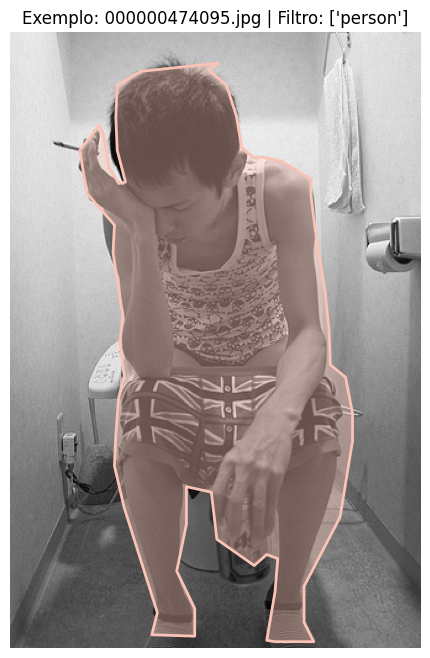

In [23]:
# 1. Escolher um ID aleatório da lista de pessoas
import random
img_random_id = random.choice(imgIds)

# 2. Carregar os metadados da imagem escolhida
img_metadata = coco.loadImgs(img_random_id)[0]
path_image = os.path.join(img_dir, img_metadata['file_name'])

# 3. ATUALIZAR a variável 'image' com o novo caminho
image = cv2.imread(path_image)
if image is None:
    print(f"Erro ao carregar a imagem: {path_image}")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 4. Confirmar as categorias presentes nesta imagem
    annIds = coco.getAnnIds(imgIds=img_metadata['id'], catIds=catIds, iscrowd=None)
    anns = coco.loadAnns(annIds)
    
    # Busca o nome da categoria para confirmar que o código "sabe" o que é
    category_names = [coco.loadCats(a['category_id'])[0]['name'] for a in anns]
    
    print(f"ID da Imagem: {img_random_id}")
    print(f"Ficheiro: {img_metadata['file_name']}")
    print(f"Categorias detectadas nesta visualização: {list(set(category_names))}")

    # 5. Configurar a visualização
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    
    # Desenha as máscaras/boxes
    coco.showAnns(anns)

    plt.axis('off')
    plt.title(f"Exemplo: {img_metadata['file_name']} | Filtro: {list(set(category_names))}")
    plt.show()

🏁
Com base no resultado, é possível ter uma noção sobre o funcionamento do modelo e a estrutura do dataset, conhecendo o formato das imagens, e o funcionamento do modelo. Nota-se que a pessoa detectada na imagem é envolvida por uma forma, denominada bounding boxes.
📌